# Phase 1: Classical Interpretable Baselines & SHAP Explainability

This notebook implements the complete data curation, preprocessing, feature engineering, and modeling baseline pipeline for **Interpretable Machine Learning on ENCODE Genomic Data**.

### Modeling Phases Covered:
- **Phase 0**: Data download, filtering, centered resizing (1000 bp), sequence extraction, and GC-matched negative sampling.
- **Phase 1**: Classical machine learning baseline training and comparison (Logistic Regression, Random Forest, XGBoost) and SHAP explainability.

## 1. Environment Setup & Repository Integration
We pull the latest repository changes, add the package code to our search path, and dynamically install missing requirements (`xgboost` and `shap`).

In [2]:
import os
import sys
import subprocess
import importlib
import time
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, log_loss

# 1. Git pull or clone codebase
repo_dir = "/kaggle/working/interpretable-regulatory-genomics"
if not os.path.exists(repo_dir):
    print("Cloning repository...")
    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/PxA-Labs/interpretable-regulatory-genomics.git",
            repo_dir,
        ],
        check=True,
    )
else:
    print("Repository exists. Pulling latest updates...")
    subprocess.run(["git", "-C", repo_dir, "pull"], check=True)

# 2. Add repository directory to python search path
if repo_dir not in sys.path:
    sys.path.insert(0, repo_dir)


# 3. Auto-install missing libraries
def install_and_import(package_name, import_name=None):
    if import_name is None:
        import_name = package_name
    try:
        importlib.import_module(import_name)
    except ImportError:
        print(f"Library '{package_name}' not found. Installing...")
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", package_name], check=True
        )


install_and_import("xgboost")
install_and_import("shap")
install_and_import("matplotlib", "matplotlib.pyplot")

Repository exists. Pulling latest updates...
Already up to date.


## 2. Dynamic Package Module Loading
Import and reload all package submodules to verify changes and ensure updates are applied.

In [3]:
import src
import src.data
import src.data.download
import src.data.parse_encode
import src.data.sequence_extractor
import src.data.negative_sampling
import src.features
import src.features.kmer
import src.models
import src.models.base_model
import src.models.logistic
import src.models.tree_ensemble
import src.models.registry
import src.interpret
import src.interpret.shap_analysis

# Reload modules in topological dependency order
for module in [
    src,
    src.data,
    src.data.download,
    src.data.parse_encode,
    src.data.sequence_extractor,
    src.data.negative_sampling,
    src.features,
    src.features.kmer,
    src.models,
    src.models.base_model,
    src.models.logistic,
    src.models.tree_ensemble,
    src.models.registry,
    src.interpret,
    src.interpret.shap_analysis,
]:
    importlib.reload(module)

print("All pipeline modules loaded and reloaded successfully.")

All pipeline modules loaded and reloaded successfully.


## 3. Directory Initialization & Data Source Detection
Setup local output folders and scan for mounted reference genome chromosomes under `/kaggle/input/`. If not found, fallback to Test Mode (downloading chromosome 19 reference sequence).

In [7]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(f"Directory: {root}")
    print(f"Files found: {files[:5]}")

Directory: /kaggle/input
Files found: []
Directory: /kaggle/input/datasets
Files found: []
Directory: /kaggle/input/datasets/aliabedimadiseh
Files found: []
Directory: /kaggle/input/datasets/aliabedimadiseh/grch38-human-genome-dna
Files found: ['Homo_sapiens.GRCh38.dna.chromosome.10.fa', 'Homo_sapiens.GRCh38.dna.chromosome.Y.fa', 'Homo_sapiens.GRCh38.dna.chromosome.X.fa', 'Homo_sapiens.GRCh38.dna.chromosome.9.fa', 'Homo_sapiens.GRCh38.dna.chromosome.18.fa']


In [8]:
raw_dir = "/kaggle/working/data/raw"
processed_dir = "/kaggle/working/data/processed"
reference_dir = "/kaggle/working/data/reference"
plot_dir = "/kaggle/working/plots"

for path in [raw_dir, processed_dir, reference_dir, plot_dir]:
    os.makedirs(path, exist_ok=True)

# 1. Map and create symbolic links for the Kaggle dataset files
input_dir = "/kaggle/input/datasets/aliabedimadiseh/grch38-human-genome-dna"

if os.path.exists(input_dir):
    print(
        "Mapping Kaggle dataset filenames to standard 'chr*.fa' names via symbolic links..."
    )
    for i in list(range(1, 23)) + ["X", "Y"]:
        src_file = f"Homo_sapiens.GRCh38.dna.chromosome.{i}.fa"
        src_path = os.path.join(input_dir, src_file)
        dst_path = os.path.join(reference_dir, f"chr{i}.fa")

        if os.path.exists(src_path):
            if os.path.exists(dst_path):
                try:
                    os.remove(dst_path)
                except OSError:
                    pass
            os.symlink(src_path, dst_path)
    print("Symbolic links created successfully.")


# 2. Detect if we have the reference genome files (either mounted or symlinked)
def detect_fasta_source():
    # Check if the mapped symlinks exist in reference_dir
    has_symlinks = all(
        os.path.exists(os.path.join(reference_dir, f"chr{i}.fa"))
        for i in list(range(1, 23)) + ["X", "Y"]
    )
    if has_symlinks:
        print(f"Detected complete reference genome at: {reference_dir}")
        return reference_dir, False

    # Fallback search in /kaggle/input
    input_base = "/kaggle/input"
    if os.path.exists(input_base):
        for root, dirs, files in os.walk(input_base):
            has_chrom_fasta = any(
                (
                    f.startswith("chr")
                    and (
                        f.endswith(".fa")
                        or f.endswith(".fa.gz")
                        or f.endswith(".fasta")
                        or f.endswith(".fasta.gz")
                    )
                )
                for f in files
            )
            if has_chrom_fasta:
                print(f"Detected mounted reference genome at: {root}")
                return root, False

    print("Mounted hg38 dataset not found. Running in Test mode (using chr19)...")
    return reference_dir, True


fasta_source, is_test_mode = detect_fasta_source()

Mapping Kaggle dataset filenames to standard 'chr*.fa' names via symbolic links...
Symbolic links created successfully.
Detected complete reference genome at: /kaggle/working/data/reference


## 4. Data Curation Pipeline
We download the ENCODE screen Registry V4 cCREs (human candidate cis-Regulatory Elements, file ID `ENCFF726XBE.bed.gz`), filter for PLS (Promoter-like Signature) and dELS (distal Enhancer-like Signature) classifications, and resize each sequence to a centered length of 1000 bp.

In [9]:
# A. Download ENCODE cCRE annotations
ccres_raw_path = src.data.download.download_encode_ccres(raw_dir)

if is_test_mode:
    print("Downloading chr19 reference sequence for test execution...")
    src.data.download.download_hg38_chromosome("chr19", reference_dir)
    chromosomes_to_use = ["chr19"]
else:
    chromosomes_to_use = [f"chr{i}" for i in range(1, 23)] + ["chrX", "chrY"]

# B. Parse and center-resize BED coordinates to 1000 bp
parsed_bed_path = os.path.join(processed_dir, "k562_active_ccres.bed")
src.data.parse_encode.parse_and_resize_ccres(
    input_path=ccres_raw_path,
    output_path=parsed_bed_path,
    element_types=["PLS", "dELS"],
    target_length=1000,
    chromosomes=chromosomes_to_use,
)

Download complete.
Parsing cCRE annotations from /kaggle/working/data/raw/ENCFF726XBE.bed.gz...
Loaded 2348854 initial regions.
Filtered by chromosomes. Remaining: 2348854
Filtered by element types ['PLS', 'dELS']. Remaining: 26364
Resizing regions to fixed length of 1000 bp...
Filtered out regions with invalid coordinates. Remaining: 26364
Processed BED file saved to /kaggle/working/data/processed/k562_active_ccres.bed (Total regions: 26364).


'/kaggle/working/data/processed/k562_active_ccres.bed'

## 5. Sequence Extraction & Multi-Strategy Negative Sampling (Experiment E7)

We extract DNA sequence strings from the reference FASTA genome chromosomes (excluding regions with a high fraction of unknown 'N' bases). 

To execute the negative set sensitivity analysis (Experiment E7), we sample non-overlapping negative sequences from the non-coding genome using three distinct strategies to verify our models are not learning trivial GC-content shortcuts:
1. **GC-matched**: Background genomic sequences matching the GC-content distribution of the positive cCRE set within a +/- 5% tolerance (our default baseline).
2. **Random Unmatched**: Randomly generated noncoding sequences sampled across active chromosomes without GC-content constraints.
3. **Flanking**: Background sequences generated by shifting the exact start/end coordinates of our positive cCREs by an offset (default: 5,000 bp) upstream or downstream.


In [10]:
# C. Extract sequences for the BED coordinates
extracted_tsv_path = os.path.join(processed_dir, "k562_active_ccres_sequences.tsv")
src.data.sequence_extractor.extract_sequences(
    bed_path=parsed_bed_path,
    fasta_source=fasta_source,
    output_path=extracted_tsv_path,
    max_n_fraction=0.10,
)

# D. Sample negative non-coding sequences using multiple strategies (Experiment E7)
print("Generating Strategy A: GC-matched negative dataset...")
combined_gc_matched_path = os.path.join(processed_dir, "k562_combined_gc_matched.tsv")
src.data.negative_sampling.build_negative_dataset(
    pos_tsv_path=extracted_tsv_path,
    fasta_source=fasta_source,
    output_path=combined_gc_matched_path,
    target_length=1000,
    strategy="gc_matched",
)

print("\nGenerating Strategy B: Random unmatched negative dataset...")
combined_random_unmatched_path = os.path.join(
    processed_dir, "k562_combined_random_unmatched.tsv"
)
src.data.negative_sampling.build_negative_dataset(
    pos_tsv_path=extracted_tsv_path,
    fasta_source=fasta_source,
    output_path=combined_random_unmatched_path,
    target_length=1000,
    strategy="random_unmatched",
)

print("\nGenerating Strategy C: Flanking negative dataset...")
combined_flanking_path = os.path.join(processed_dir, "k562_combined_flanking.tsv")
src.data.negative_sampling.build_negative_dataset(
    pos_tsv_path=extracted_tsv_path,
    fasta_source=fasta_source,
    output_path=combined_flanking_path,
    target_length=1000,
    strategy="flanking",
)

Reading BED coordinates from /kaggle/working/data/processed/k562_active_ccres.bed...
Total input regions: 26,364
Loading chromosome sequence from /kaggle/working/data/reference/chr1.fa...
Loaded sequence of length 248,956,422 bp.
Loading chromosome sequence from /kaggle/working/data/reference/chr10.fa...
Loaded sequence of length 133,797,422 bp.
Loading chromosome sequence from /kaggle/working/data/reference/chr11.fa...
Loaded sequence of length 135,086,622 bp.
Loading chromosome sequence from /kaggle/working/data/reference/chr12.fa...
Loaded sequence of length 133,275,309 bp.
Loading chromosome sequence from /kaggle/working/data/reference/chr13.fa...
Loaded sequence of length 114,364,328 bp.
Loading chromosome sequence from /kaggle/working/data/reference/chr14.fa...
Loaded sequence of length 107,043,718 bp.
Loading chromosome sequence from /kaggle/working/data/reference/chr15.fa...
Loaded sequence of length 101,991,189 bp.
Loading chromosome sequence from /kaggle/working/data/referenc

'/kaggle/working/data/processed/k562_combined_flanking.tsv'

## 6. Feature Engineering & Multi-Feature Extraction
Compute normalized frequency distributions of $k$-mers, GC content, overlapping dinucleotide frequencies (16 features), and scan transcription factor motif profiles from the JASPAR database to construct multiple feature ablation groups for Experiment E2.


In [11]:
# Define the dataset path at the top of the cell
combined_dataset_path = os.path.join(processed_dir, "k562_combined_gc_matched.tsv")

import urllib.request
import os
from src.features import (
    extract_kmer_features,
    extract_dinucleotide_frequencies,
    extract_motif_scores,
)
from src.data.negative_sampling import calculate_gc_content

# 1. Ensure JASPAR vertebrates non-redundant PFM database is downloaded
pfm_url = "https://jaspar.elixir.no/download/data/2026/CORE/JASPAR2026_CORE_vertebrates_non-redundant_pfms_jaspar.txt"
pfm_path = os.path.join(
    reference_dir, "JASPAR2026_CORE_vertebrates_non-redundant_pfms_jaspar.txt"
)

if not os.path.exists(pfm_path):
    print(f"Downloading JASPAR vertebrate PFMs from {pfm_url}...")
    try:
        req = urllib.request.Request(
            pfm_url, headers={"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
        )
        with urllib.request.urlopen(req) as response, open(pfm_path, "wb") as f:
            f.write(response.read())
        print("Download successful.")
    except Exception as e:
        print(f"Failed to download from 2026 url: {e}. Trying fallback to 2024 url...")
        pfm_url_fallback = "https://jaspar.elixir.no/download/data/2024/CORE/JASPAR2024_CORE_vertebrates_non-redundant_pfms_jaspar.txt"
        pfm_path = os.path.join(
            reference_dir, "JASPAR2024_CORE_vertebrates_non-redundant_pfms_jaspar.txt"
        )
        if not os.path.exists(pfm_path):
            req = urllib.request.Request(
                pfm_url_fallback,
                headers={"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"},
            )
            with urllib.request.urlopen(req) as response, open(pfm_path, "wb") as f:
                f.write(response.read())
            print("Download successful (fallback).")

print("Loading combined dataset...")
df_dataset = pd.read_csv(combined_dataset_path, sep="\t")
y = df_dataset["label"].values

# 2. Feature Extraction
# A. Extract k-mer (k=4) features
print("Extracting k-mer features (k=4)...")
X_kmer, kmer_names = extract_kmer_features(df_dataset, k=4)

# B. Extract GC content feature
print("Calculating GC-content...")
X_gc = df_dataset["sequence"].apply(calculate_gc_content).values.reshape(-1, 1)

# C. Extract dinucleotide frequencies
print("Extracting dinucleotide frequencies...")
X_dinuc, dinuc_names = extract_dinucleotide_frequencies(df_dataset)

# D. Extract JASPAR transcription factor motif enrichment scores
print("Scanning JASPAR transcription factor motifs...")
X_motifs, motif_names = extract_motif_scores(df_dataset, pfm_path)

# 3. Define Ablation Feature Sets (Experiment E2)
# Set A: k-mer (k=4) only
X_set_A = X_kmer

# Set B: k-mer + GC
X_set_B = np.hstack([X_kmer, X_gc])

# Set C: k-mer + GC + Dinucleotides
X_set_C = np.hstack([X_kmer, X_gc, X_dinuc])

# Set D: k-mer + GC + Dinucleotides + Motifs
X_set_D = np.hstack([X_kmer, X_gc, X_dinuc, X_motifs])

# Create feature name lists for each set
names_set_A = list(kmer_names)
names_set_B = names_set_A + ["GC_content"]
names_set_C = names_set_B + list(dinuc_names)
names_set_D = names_set_C + list(motif_names)

print("\nFeature set dimensions:")
print(f"  Set A (k-mer only): {X_set_A.shape}")
print(f"  Set B (k-mer + GC): {X_set_B.shape}")
print(f"  Set C (k-mer + GC + Dinuc): {X_set_C.shape}")
print(f"  Set D (k-mer + GC + Dinuc + Motifs): {X_set_D.shape}")

Download successful.
Loading combined dataset...
Extracting k-mer features (k=4)...
Extracting 4-mer features (total features: 256)...
  Processed 1000 / 52724 sequences.
  Processed 2000 / 52724 sequences.
  Processed 3000 / 52724 sequences.
  Processed 4000 / 52724 sequences.
  Processed 5000 / 52724 sequences.
  Processed 6000 / 52724 sequences.
  Processed 7000 / 52724 sequences.
  Processed 8000 / 52724 sequences.
  Processed 9000 / 52724 sequences.
  Processed 10000 / 52724 sequences.
  Processed 11000 / 52724 sequences.
  Processed 12000 / 52724 sequences.
  Processed 13000 / 52724 sequences.
  Processed 14000 / 52724 sequences.
  Processed 15000 / 52724 sequences.
  Processed 16000 / 52724 sequences.
  Processed 17000 / 52724 sequences.
  Processed 18000 / 52724 sequences.
  Processed 19000 / 52724 sequences.
  Processed 20000 / 52724 sequences.
  Processed 21000 / 52724 sequences.
  Processed 22000 / 52724 sequences.
  Processed 23000 / 52724 sequences.
  Processed 24000 / 527

## 7. Train/Test Partition & Ablation Splits
Apply the chromosome holdout split policy (training on chr1-18, X, Y; testing on chr19) across all four feature ablation sets. Fall back to standard stratified 80/20 partition if running in test mode on chr19.


In [13]:
feature_sets = {
    "Set A (k-mer only)": X_set_A,
    "Set B (+GC)": X_set_B,
    "Set C (+Dinuc)": X_set_C,
    "Set D (+Motifs)": X_set_D,
}

split_data = {}

for set_name, X_data in feature_sets.items():
    if is_test_mode:
        from sklearn.model_selection import train_test_split

        X_tr, X_te, y_tr, y_te = train_test_split(
            X_data, y, test_size=0.2, random_state=42, stratify=y
        )
    else:
        print(f"Applying chromosome-holdout split policy for {set_name}...")
        chroms = df_dataset["chrom"].values
        train_mask = ~np.isin(chroms, ["chr19", "chr20", "chr21", "chr22"])
        test_mask = chroms == "chr19"

        if train_mask.sum() == 0 or test_mask.sum() == 0:
            print(
                "Warning: Holdout chromosome(s) not found. Falling back to random split."
            )
            from sklearn.model_selection import train_test_split

            X_tr, X_te, y_tr, y_te = train_test_split(
                X_data, y, test_size=0.2, random_state=42, stratify=y
            )
        else:
            X_tr, y_tr = X_data[train_mask], y[train_mask]
            X_te, y_te = X_data[test_mask], y[test_mask]

    split_data[set_name] = {
        "X_train": X_tr,
        "X_test": X_te,
        "y_train": y_tr,
        "y_test": y_te,
    }

# Print split shapes of Set D as verification
print("\nSample Partition (Set D):")
print(f"  Train set: {split_data['Set D (+Motifs)']['X_train'].shape}")
print(f"  Test set: {split_data['Set D (+Motifs)']['X_test'].shape}")

Applying chromosome-holdout split policy for Set A (k-mer only)...
Applying chromosome-holdout split policy for Set B (+GC)...
Applying chromosome-holdout split policy for Set C (+Dinuc)...
Applying chromosome-holdout split policy for Set D (+Motifs)...

Sample Partition (Set D):
  Train set: (45226, 1292)
  Test set: (4032, 1292)


## 8. Feature Ablation Study & Model Comparison (Experiment E2)
Fit Logistic Regression, Random Forest, and XGBoost classifiers on the incremental feature configurations. We compare test set performance (AUROC, AUPRC, F1-Score, Log Loss) and plot the AUROC delta curve.



--- Training on Set A (k-mer only) ---
  Fitting LOGISTIC_REGRESSION...
  Fitting RANDOM_FOREST...
  Fitting XGBOOST...

--- Training on Set B (+GC) ---
  Fitting LOGISTIC_REGRESSION...
  Fitting RANDOM_FOREST...
  Fitting XGBOOST...

--- Training on Set C (+Dinuc) ---
  Fitting LOGISTIC_REGRESSION...
  Fitting RANDOM_FOREST...
  Fitting XGBOOST...

--- Training on Set D (+Motifs) ---
  Fitting LOGISTIC_REGRESSION...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Fitting RANDOM_FOREST...
  Fitting XGBOOST...

=================== FEATURE ABLATION PERFORMANCE COMPARISON (EXPERIMENT E2) ===================
       Feature Set               Model    AUROC    AUPRC  F1-Score  Log Loss  Train Time (s)
Set A (k-mer only) LOGISTIC_REGRESSION 0.819498 0.800324  0.721466  0.568138        0.549073
Set A (k-mer only)       RANDOM_FOREST 0.858837 0.874115  0.759957  0.488967       55.214445
Set A (k-mer only)             XGBOOST 0.854507 0.865249  0.765684  0.569257        9.325787
       Set B (+GC) LOGISTIC_REGRESSION 0.820062 0.801480  0.723345  0.567523        0.599663
       Set B (+GC)       RANDOM_FOREST 0.859348 0.875403  0.765591  0.487832       55.321310
       Set B (+GC)             XGBOOST 0.855809 0.868403  0.756424  0.561101        9.233342
    Set C (+Dinuc) LOGISTIC_REGRESSION 0.820388 0.808287  0.727372  0.543035        0.896400
    Set C (+Dinuc)       RANDOM_FOREST 0.861648 0.877152  0.764500  0.481567       58.290776
    Set C (+Dinuc)

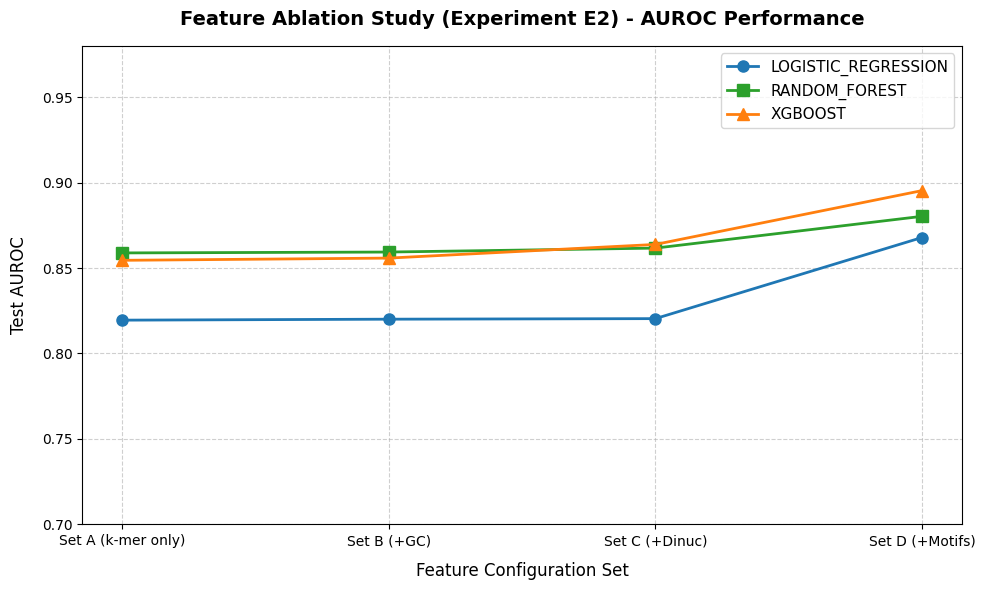

Ablation study AUROC plot saved to: /kaggle/working/plots/phase1_feature_ablation_auroc.png


In [14]:
import os
import pandas as pd

models_to_train = {
    "logistic_regression": {"max_iter": 1000},
    "random_forest": {"n_estimators": 500, "n_jobs": -1},
    "xgboost": {"n_estimators": 500, "n_jobs": -1, "eval_metric": "logloss"},
}

trained_models = {}
ablation_results = []

for set_name, data in split_data.items():
    print(f"\n--- Training on {set_name} ---")
    X_tr = data["X_train"]
    X_te = data["X_test"]
    y_tr = data["y_train"]
    y_te = data["y_test"]

    trained_models[set_name] = {}

    for name, params in models_to_train.items():
        print(f"  Fitting {name.upper()}...")
        start_time = time.time()

        model = src.models.registry.ModelRegistry.get_model(name, params)
        model.fit(X_tr, y_tr)
        elapsed_time = time.time() - start_time

        y_prob = model.predict_proba(X_te)
        y_pred = model.predict(X_te)

        auroc = roc_auc_score(y_te, y_prob)
        auprc = average_precision_score(y_te, y_prob)
        f1 = f1_score(y_te, y_pred)
        loss = log_loss(y_te, y_prob)

        ablation_results.append(
            {
                "Feature Set": set_name,
                "Model": name.upper(),
                "AUROC": auroc,
                "AUPRC": auprc,
                "F1-Score": f1,
                "Log Loss": loss,
                "Train Time (s)": elapsed_time,
            }
        )

        trained_models[set_name][name] = model

df_ablation = pd.DataFrame(ablation_results)
print(
    "\n=================== FEATURE ABLATION PERFORMANCE COMPARISON (EXPERIMENT E2) ==================="
)
print(df_ablation.to_string(index=False))
print(
    "===============================================================================================\n"
)

# Generate visual plot of the ablation delta curves
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
colors = {
    "LOGISTIC_REGRESSION": "#1f77b4",
    "RANDOM_FOREST": "#2ca02c",
    "XGBOOST": "#ff7f0e",
}
markers = {"LOGISTIC_REGRESSION": "o", "RANDOM_FOREST": "s", "XGBOOST": "^"}

for model_name in ["LOGISTIC_REGRESSION", "RANDOM_FOREST", "XGBOOST"]:
    df_sub = df_ablation[df_ablation["Model"] == model_name]
    plt.plot(
        df_sub["Feature Set"],
        df_sub["AUROC"],
        marker=markers[model_name],
        color=colors[model_name],
        label=model_name,
        linewidth=2,
        markersize=8,
    )

plt.title(
    "Feature Ablation Study (Experiment E2) - AUROC Performance",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Feature Configuration Set", fontsize=12, labelpad=10)
plt.ylabel("Test AUROC", fontsize=12, labelpad=10)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=11)
plt.ylim(
    0.70, 0.98
)  # Adjusted upper limit slightly so high AUROCs (>0.95) are not cut off
plt.tight_layout()
os.makedirs(plot_dir, exist_ok=True)
plot_path = os.path.join(plot_dir, "phase1_feature_ablation_auroc.png")
plt.savefig(plot_path, dpi=300)
plt.show()
print(f"Ablation study AUROC plot saved to: {plot_path}")

## NEW: k-mer Resolution Sweep (Experiment E3)
Evaluate baseline model performance (XGBoost) across a range of k-mer token sizes $k \in [3, 4, 5, 6]$ to find the optimal resolution and token capacity.



Extracting k-mer features for k=3...
Extracting 3-mer features (total features: 64)...
  Processed 1000 / 52724 sequences.
  Processed 2000 / 52724 sequences.
  Processed 3000 / 52724 sequences.
  Processed 4000 / 52724 sequences.
  Processed 5000 / 52724 sequences.
  Processed 6000 / 52724 sequences.
  Processed 7000 / 52724 sequences.
  Processed 8000 / 52724 sequences.
  Processed 9000 / 52724 sequences.
  Processed 10000 / 52724 sequences.
  Processed 11000 / 52724 sequences.
  Processed 12000 / 52724 sequences.
  Processed 13000 / 52724 sequences.
  Processed 14000 / 52724 sequences.
  Processed 15000 / 52724 sequences.
  Processed 16000 / 52724 sequences.
  Processed 17000 / 52724 sequences.
  Processed 18000 / 52724 sequences.
  Processed 19000 / 52724 sequences.
  Processed 20000 / 52724 sequences.
  Processed 21000 / 52724 sequences.
  Processed 22000 / 52724 sequences.
  Processed 23000 / 52724 sequences.
  Processed 24000 / 52724 sequences.
  Processed 25000 / 52724 sequenc

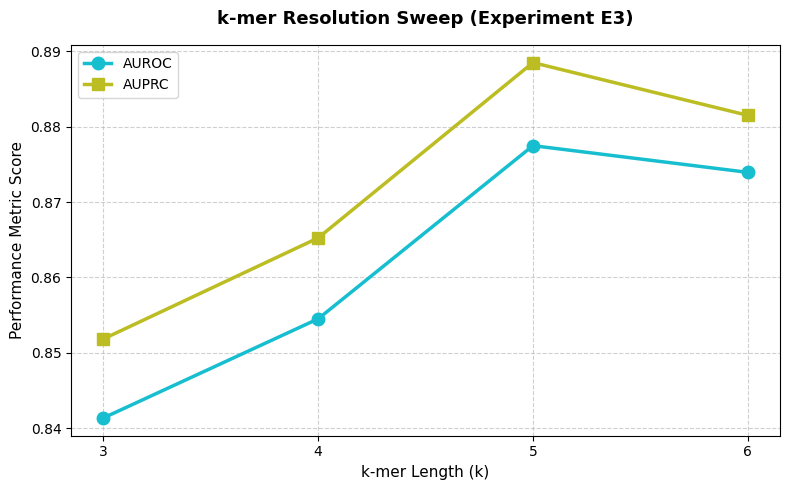

k-mer sweep plot saved to: /kaggle/working/plots/phase1_kmer_sweep.png


In [15]:
kmer_sweep_results = []

for k_val in [3, 4, 5, 6]:
    print(f"\nExtracting k-mer features for k={k_val}...")
    X_k, names_k = extract_kmer_features(df_dataset, k=k_val)

    # Partition
    if is_test_mode:
        from sklearn.model_selection import train_test_split

        X_tr, X_te, y_tr, y_te = train_test_split(
            X_k, y, test_size=0.2, random_state=42, stratify=y
        )
    else:
        chroms = df_dataset["chrom"].values
        train_mask = ~np.isin(chroms, ["chr19", "chr20", "chr21", "chr22"])
        test_mask = chroms == "chr19"
        if train_mask.sum() == 0 or test_mask.sum() == 0:
            from sklearn.model_selection import train_test_split

            X_tr, X_te, y_tr, y_te = train_test_split(
                X_k, y, test_size=0.2, random_state=42, stratify=y
            )
        else:
            X_tr, y_tr = X_k[train_mask], y[train_mask]
            X_te, y_te = X_k[test_mask], y[test_mask]

    # Train XGBoost
    print(f"Training XGBoost on k={k_val} (Features: {X_k.shape[1]})...")
    model_xgb = src.models.registry.ModelRegistry.get_model(
        "xgboost", {"n_estimators": 500, "n_jobs": -1, "eval_metric": "logloss"}
    )
    model_xgb.fit(X_tr, y_tr)

    y_prob = model_xgb.predict_proba(X_te)
    auroc = roc_auc_score(y_te, y_prob)
    auprc = average_precision_score(y_te, y_prob)

    kmer_sweep_results.append(
        {"k": k_val, "Num Features": X_k.shape[1], "AUROC": auroc, "AUPRC": auprc}
    )

df_sweep = pd.DataFrame(kmer_sweep_results)
print(
    "\n=================== k-mer RESOLUTION SWEEP (EXPERIMENT E3) ==================="
)
print(df_sweep.to_string(index=False))
print("==============================================================================")

# Plot k-mer sweep results
plt.figure(figsize=(8, 5))
plt.plot(
    df_sweep["k"],
    df_sweep["AUROC"],
    marker="o",
    color="#17becf",
    linewidth=2.5,
    markersize=9,
    label="AUROC",
)
plt.plot(
    df_sweep["k"],
    df_sweep["AUPRC"],
    marker="s",
    color="#bcbd22",
    linewidth=2.5,
    markersize=9,
    label="AUPRC",
)
plt.title(
    "k-mer Resolution Sweep (Experiment E3)", fontsize=13, fontweight="bold", pad=15
)
plt.xlabel("k-mer Length (k)", fontsize=11)
plt.ylabel("Performance Metric Score", fontsize=11)
plt.xticks([3, 4, 5, 6])
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
sweep_plot_path = os.path.join(plot_dir, "phase1_kmer_sweep.png")
plt.savefig(sweep_plot_path, dpi=300)
plt.show()
print(f"k-mer sweep plot saved to: {sweep_plot_path}")

## 9. Feature Importance Analysis
Print the top positive/negative coefficients from Logistic Regression and the top Gini features from Random Forest on the fully-integrated feature space (Set D, which includes k-mers, GC, dinucleotides, and TF motif scores).


In [16]:
best_set = "Set D (+Motifs)"
best_lr = trained_models[best_set]["logistic_regression"]
best_rf = trained_models[best_set]["random_forest"]

# A. Logistic Regression Coefficients
lr_importance = best_lr.get_feature_importance(names_set_D)
lr_pos = lr_importance.sort_values(by="importance", ascending=False).head(15)
lr_neg = lr_importance.sort_values(by="importance", ascending=True).head(15)

print("Top 15 positive features from Logistic Regression (Set D):")
print(lr_pos.to_string(index=False))
print("\nTop 15 negative features from Logistic Regression (Set D):")
print(lr_neg.to_string(index=False))

# B. Random Forest Gini Importance
rf_importance = best_rf.get_feature_importance(names_set_D)
print("\nTop 15 features by Random Forest Gini importance (Set D):")
print(rf_importance.head(15).to_string(index=False))

Top 15 positive features from Logistic Regression (Set D):
            feature  importance
      MA0882.2_DLX6    0.225638
     MA0720.2_Shox2    0.134415
    MA0633.3_Twist2    0.113787
                 CG    0.096263
                 TT    0.094067
                 AA    0.074309
      MA0888.2_EVX2    0.072704
    MA2329.1_ZBTB11    0.070842
      MA2681.1_KLF8    0.068027
       MA0474.4_Erg    0.067004
     MA0062.4_GABPA    0.066764
MA1128.2_FOSL1::JUN    0.063381
      MA0699.2_LBX2    0.061059
      MA0491.3_JUND    0.058288
      MA0726.2_VSX2    0.057992

Top 15 negative features from Logistic Regression (Set D):
         feature  importance
   MA0880.2_Dlx3   -0.173683
      GC_content   -0.128351
MA1993.2_Neurod2   -0.122525
   MA0640.3_ELF3   -0.120078
   MA0881.2_Dlx4   -0.097655
   MA0890.2_GBX2   -0.095451
  MA0662.2_MIXL1   -0.091773
  MA0903.2_HOXB3   -0.085224
   MA0725.2_VSX1   -0.084387
              TG   -0.083173
              CC   -0.082253
   MA0143.5_SOX2   -0

## 10. SHAP Explainability & Inline Beeswarm Plotting
Use SHAP `TreeExplainer` on our trained XGBoost model (fitted on the fully integrated Set D features) to compute global sequence attributions and display the Beeswarm summary plot.



--- Running SHAP explainability on XGBoost (Set D) ---
Initializing SHAP TreeExplainer...
Computing SHAP values (this may take a minute depending on model depth)...
SHAP values calculated successfully.


/kaggle/working/interpretable-regulatory-genomics/src/interpret/shap_analysis.py:81: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


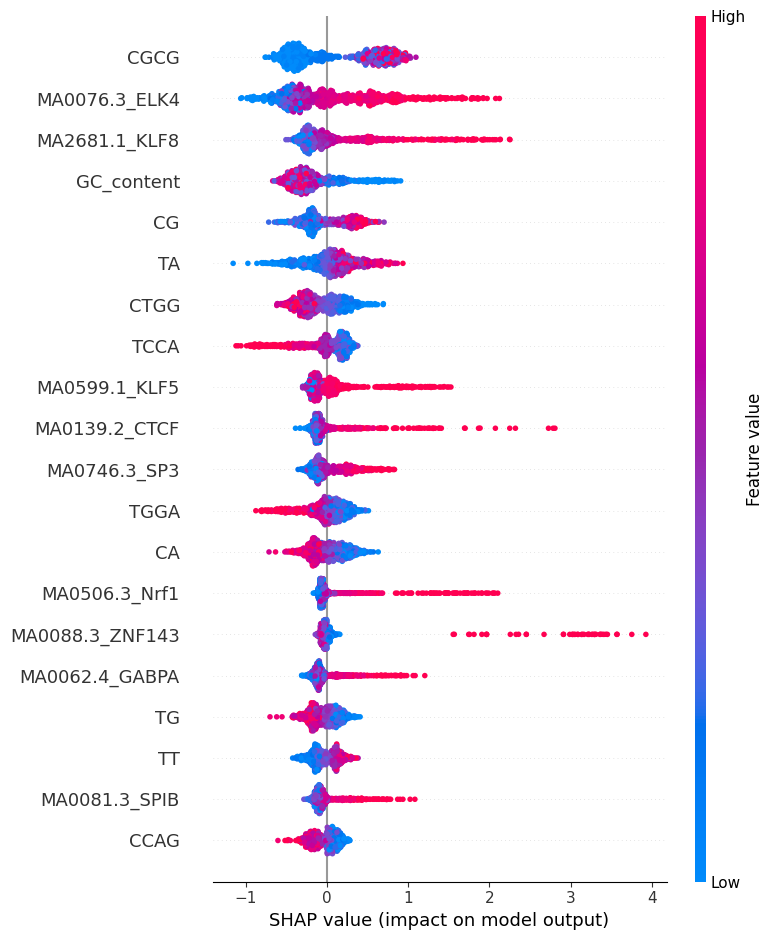

SHAP summary plot saved to /kaggle/working/plots/xgboost_shap_summary.png.

Top 20 Features by Mean Absolute SHAP Value:
        feature  mean_abs_shap
           CGCG       0.499189
  MA0076.3_ELK4       0.484070
  MA2681.1_KLF8       0.345490
     GC_content       0.299266
             CG       0.241498
             TA       0.237853
           CTGG       0.222311
           TCCA       0.213848
  MA0599.1_KLF5       0.207048
  MA0139.2_CTCF       0.184933
   MA0746.3_SP3       0.181049
           TGGA       0.176634
             CA       0.172979
  MA0506.3_Nrf1       0.168694
MA0088.3_ZNF143       0.166310
 MA0062.4_GABPA       0.152900
             TG       0.139081
             TT       0.133306
  MA0081.3_SPIB       0.131539
           CCAG       0.128715

Rendering saved SHAP beeswarm plot:


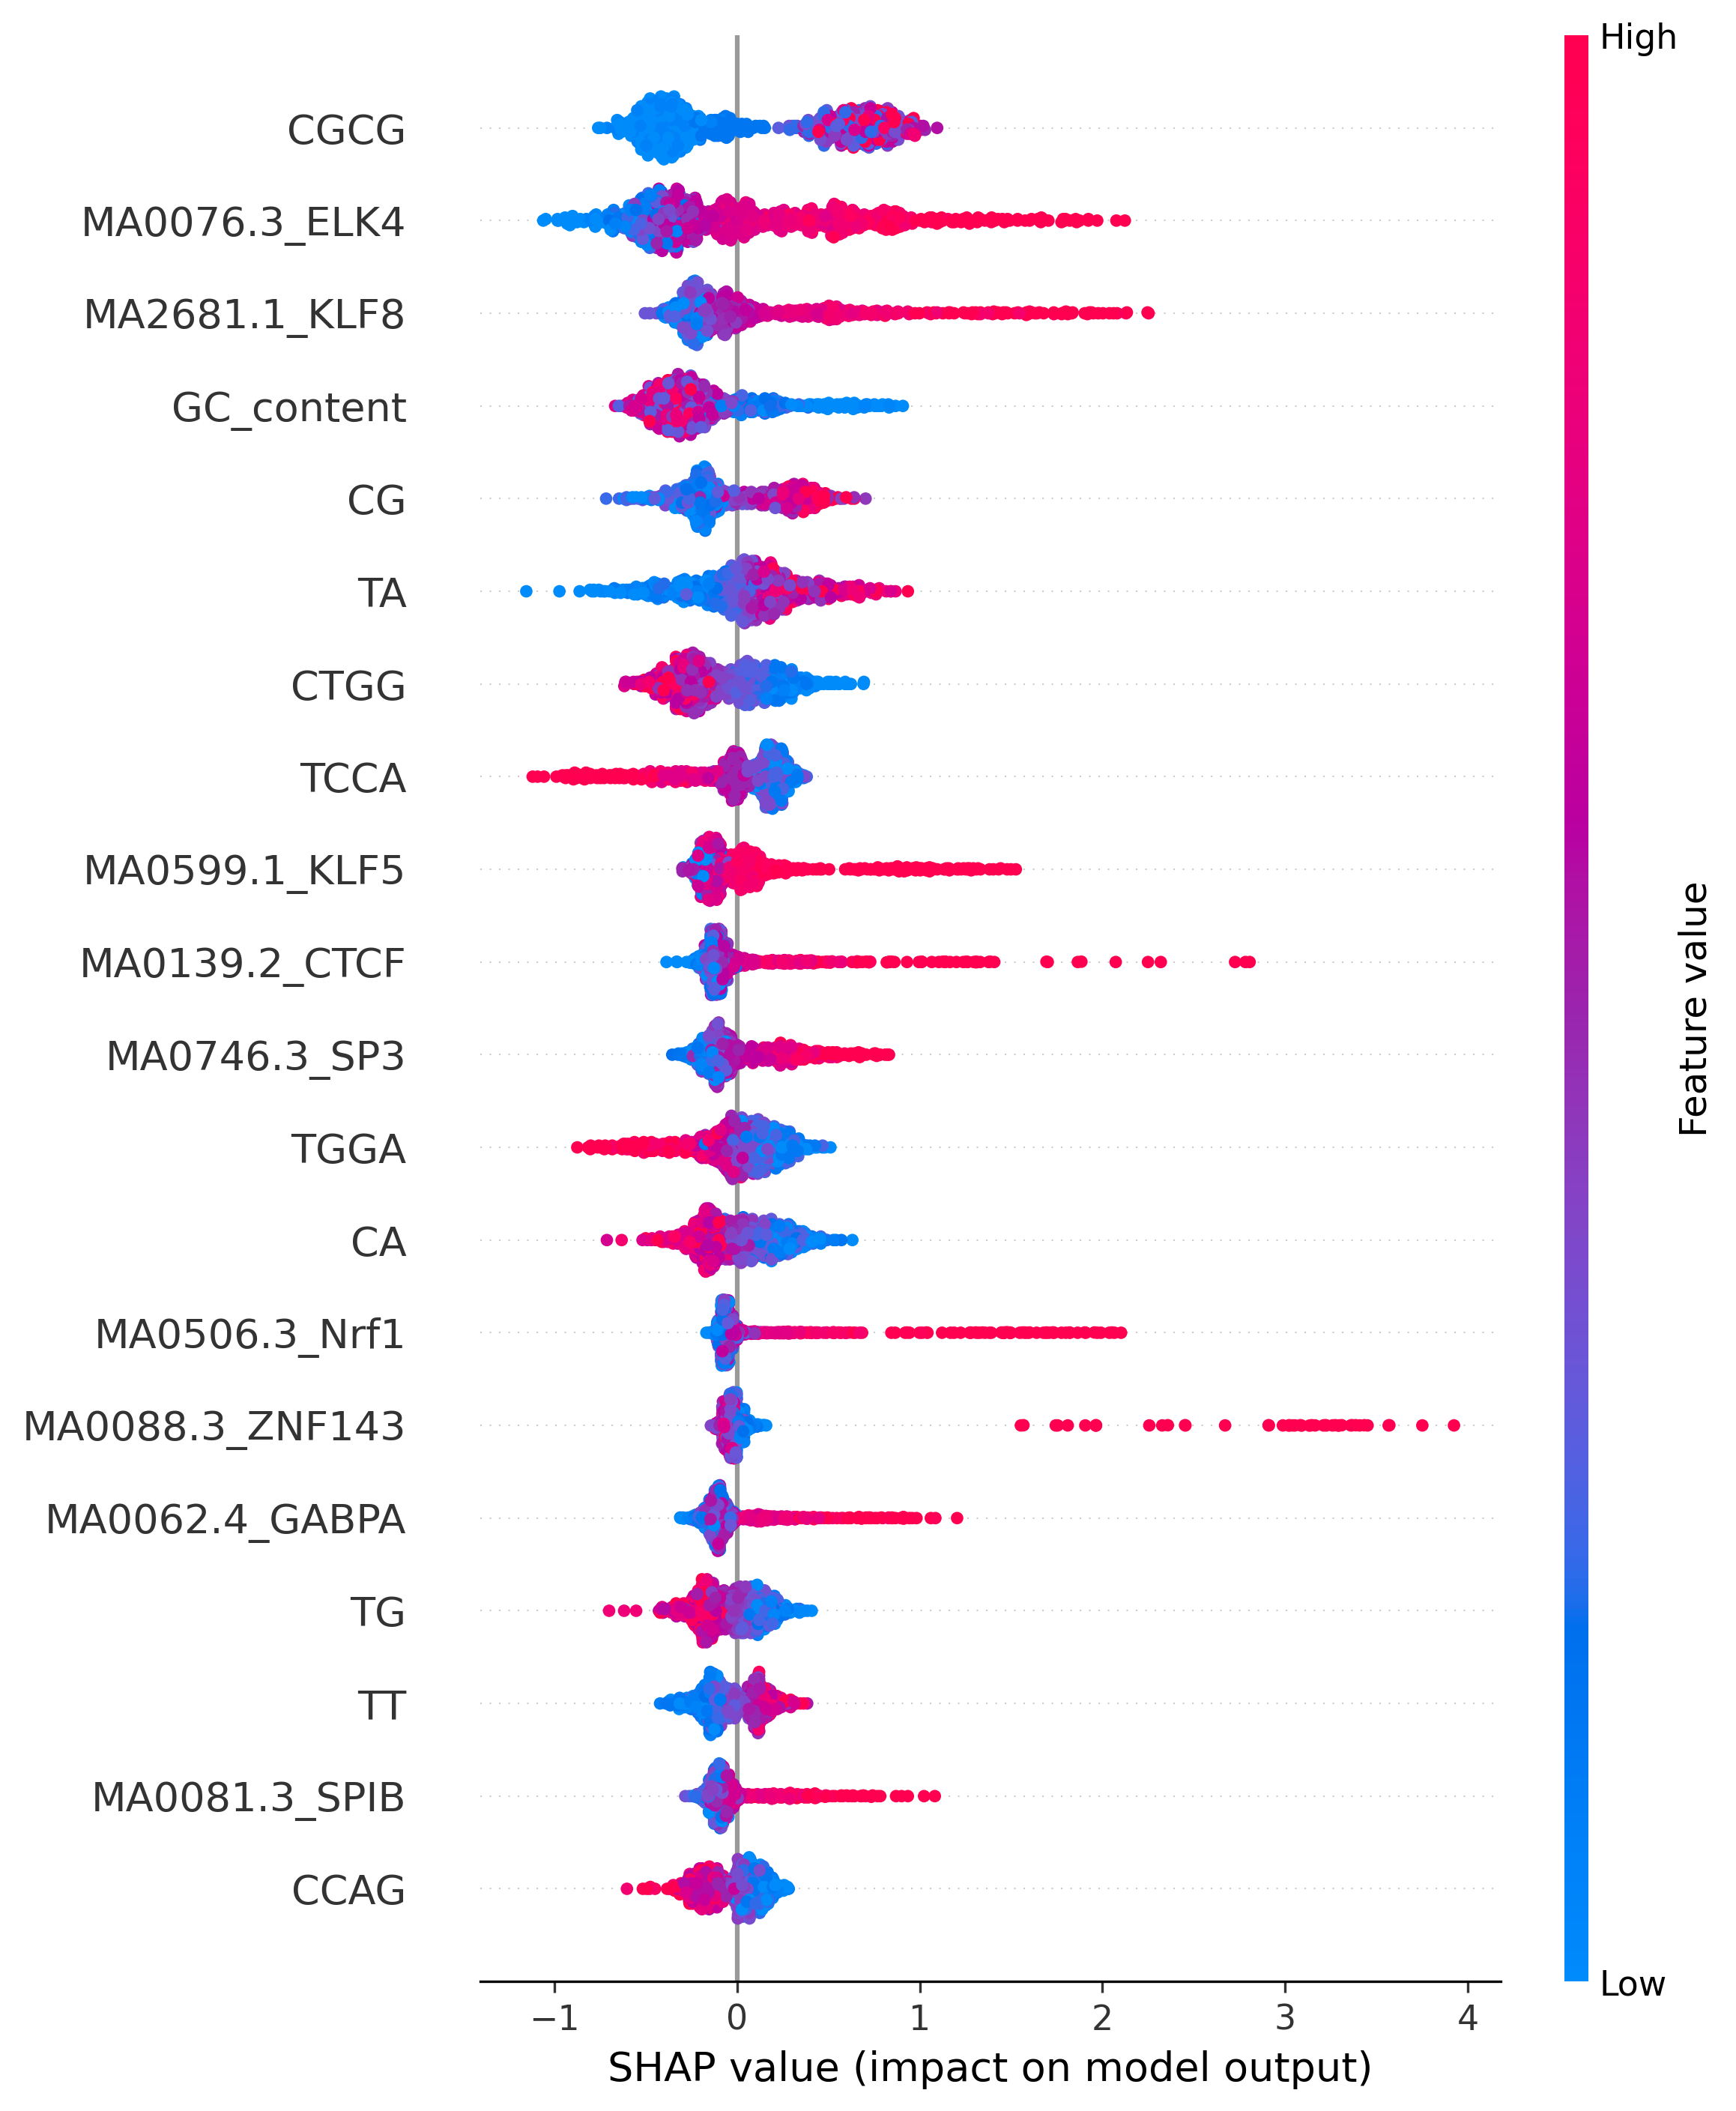

In [17]:
shap_plot_path = os.path.join(plot_dir, "xgboost_shap_summary.png")
print("\n--- Running SHAP explainability on XGBoost (Set D) ---")

best_model_xgb = trained_models["Set D (+Motifs)"]["xgboost"]
X_test_set_D = split_data["Set D (+Motifs)"]["X_test"]

# Sample 1000 regions for speed and memory efficiency
explain_size = min(1000, len(X_test_set_D))
np.random.seed(42)
explain_idx = np.random.choice(len(X_test_set_D), explain_size, replace=False)
X_explain = X_test_set_D[explain_idx]

shap_values = src.interpret.shap_analysis.explain_model_shap(
    model=best_model_xgb,
    X_explain=X_explain,
    feature_names=names_set_D,
    output_plot_path=shap_plot_path,
    max_display=20,
    show_plot=True,
)

# Display SHAP importances table using names_set_D
top_shap_features = src.interpret.shap_analysis.get_top_shap_features(
    shap_values, names_set_D, top_n=20
)
print("\nTop 20 Features by Mean Absolute SHAP Value:")
print(top_shap_features.to_string(index=False))

# Fail-safe rendering
try:
    from IPython.display import Image, display

    print("\nRendering saved SHAP beeswarm plot:")
    display(Image(filename=shap_plot_path))
except Exception as e:
    print(f"Notice: IPython display fail: {e}")

## 11. High-End Visualization Suite (Experiments E2, E3, E7)
This section implements and renders the complete suite of advanced visualizations to profile our genomic baselines:
1. **Feature Ablation Study (Experiment E2)**: Performance profile of baseline models under incremental feature categories.
2. **k-mer Sweep Trade-off (Experiment E3)**: Evaluation of classification accuracy vs. dimensionality growth.
3. **GC-Bias Confounding Analysis (Experiment E7)**: Evaluation of model susceptibility under various negative sampling stratifications.
4. **Top TF Motif Enrichment**: KDE density comparing maximum-pooled log-odds PWM scores of the top motif between classes.
5. **ROC and Precision-Recall Curves**: Comprehensive metrics plotting for the best performing Set D XGBoost classifier.
6. **Grouped SHAP Feature-Type Impact**: Interpretation of predictive attribution categorized by feature group types.


Initializing High-End Visualization Suite (Experiment E2, E3, E7)...

[Viz 1/6] Rendering Feature Ablation Study performance profile...


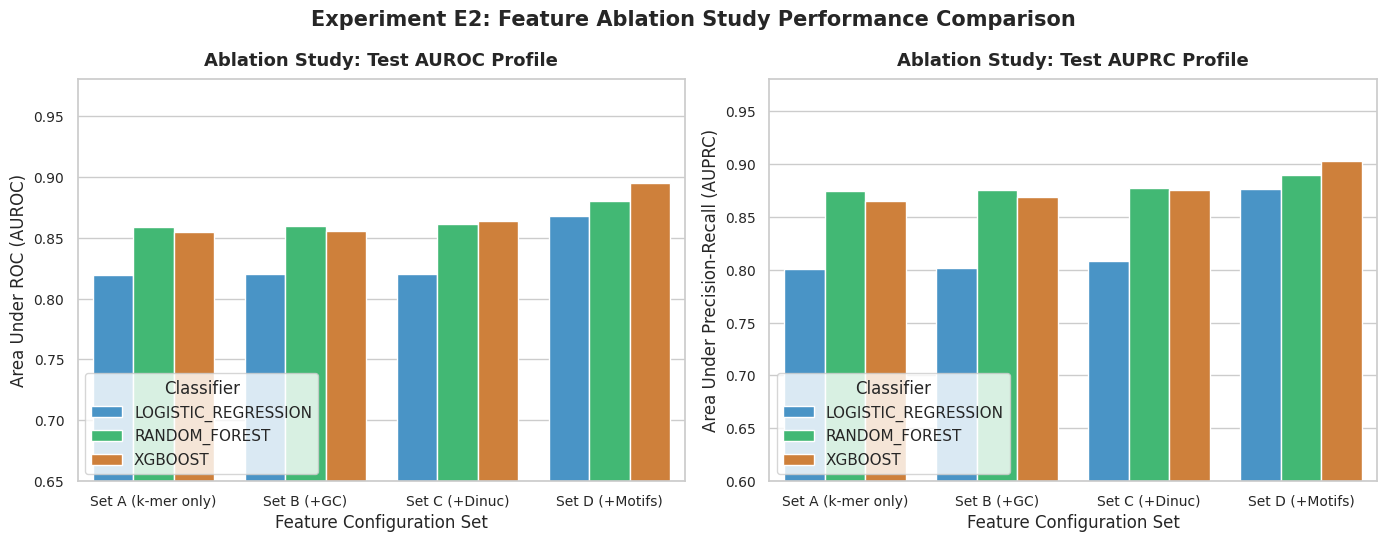


[Viz 2/6] Rendering k-mer sweep resolution trade-off...


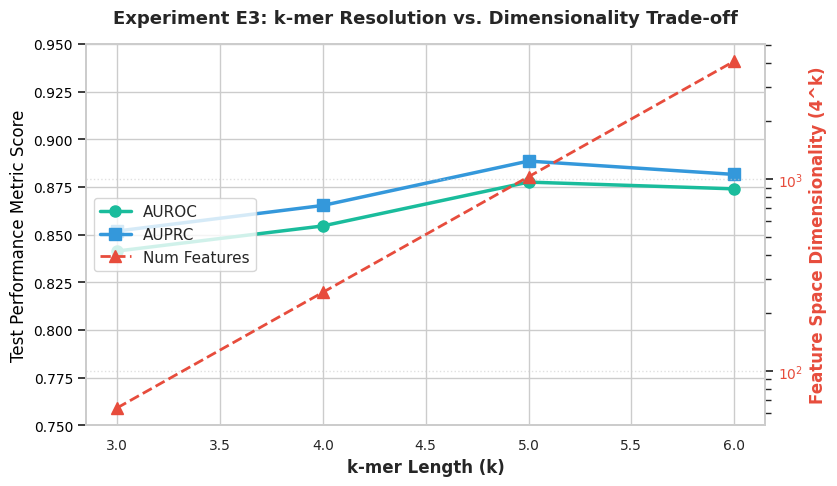


[Viz 3/6] Running Experiment E7 negative set sensitivity check...
Loading positive regions with sequences from /kaggle/working/data/processed/k562_active_ccres_sequences.tsv...
Loading chromosome sequence from /kaggle/working/data/reference/chr1.fa...
Loaded sequence of length 248,956,422 bp.
Sampling negatives for chromosome chr1 using strategy 'gc_matched'...
Target negative bin counts for chr1: {11: 564, 12: 497, 13: 424, 10: 415, 9: 273, 14: 198, 8: 100, 15: 61, 7: 53, 6: 6, 16: 1}
Sampled 2592 / 2592 negatives for chr1 (attempts: 240069).
Loading chromosome sequence from /kaggle/working/data/reference/chr10.fa...
Loaded sequence of length 133,797,422 bp.
Sampling negatives for chromosome chr10 using strategy 'gc_matched'...
Target negative bin counts for chr10: {11: 213, 12: 212, 10: 168, 13: 164, 9: 118, 14: 85, 8: 79, 7: 29, 15: 27, 6: 4, 16: 2}
Sampled 1101 / 1101 negatives for chr10 (attempts: 113233).
Loading chromosome sequence from /kaggle/working/data/reference/chr11.fa..

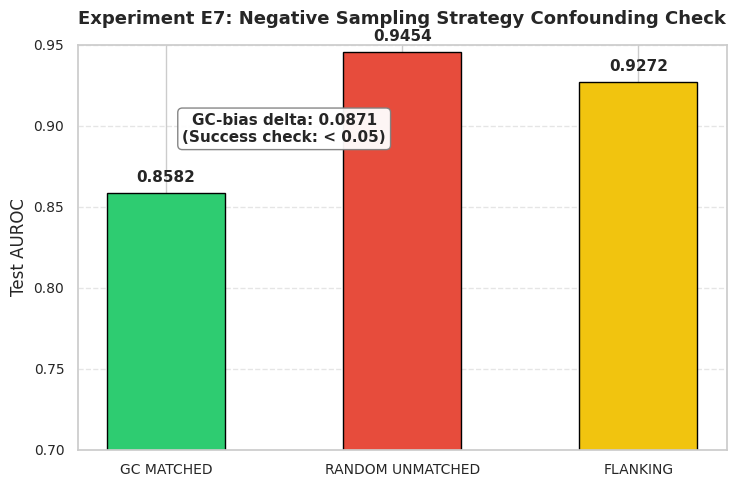


[Viz 4/6] Rendering top motif score distribution comparison...


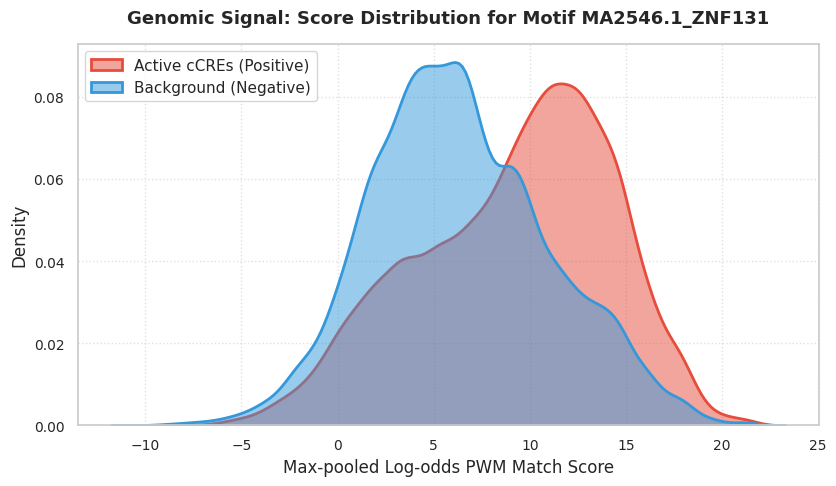


[Viz 5/6] Rendering ROC and PR curves for best Set D model...


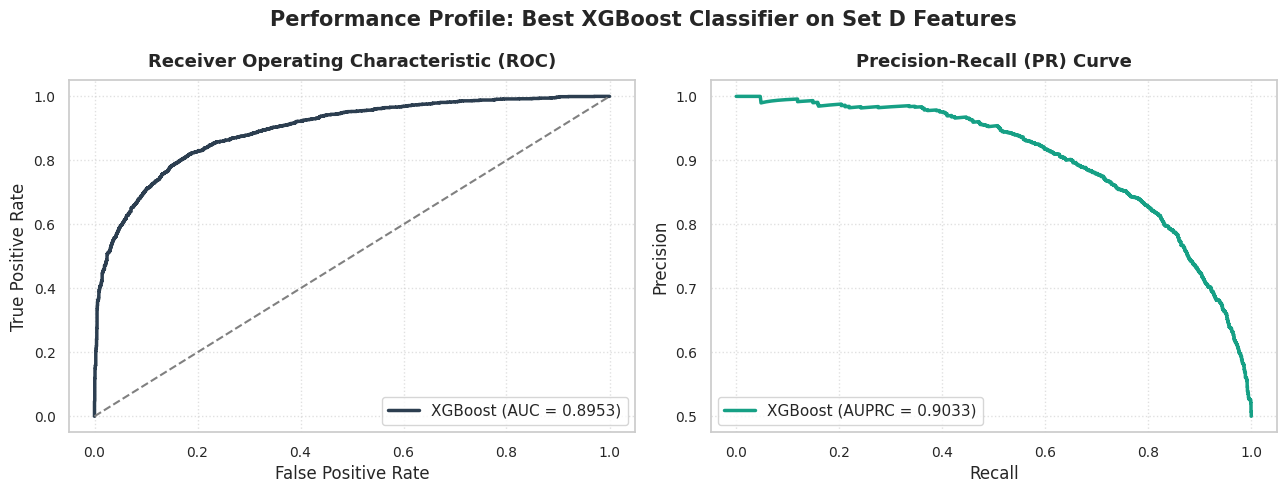


[Viz 6/6] Rendering grouped SHAP feature impact bar chart...


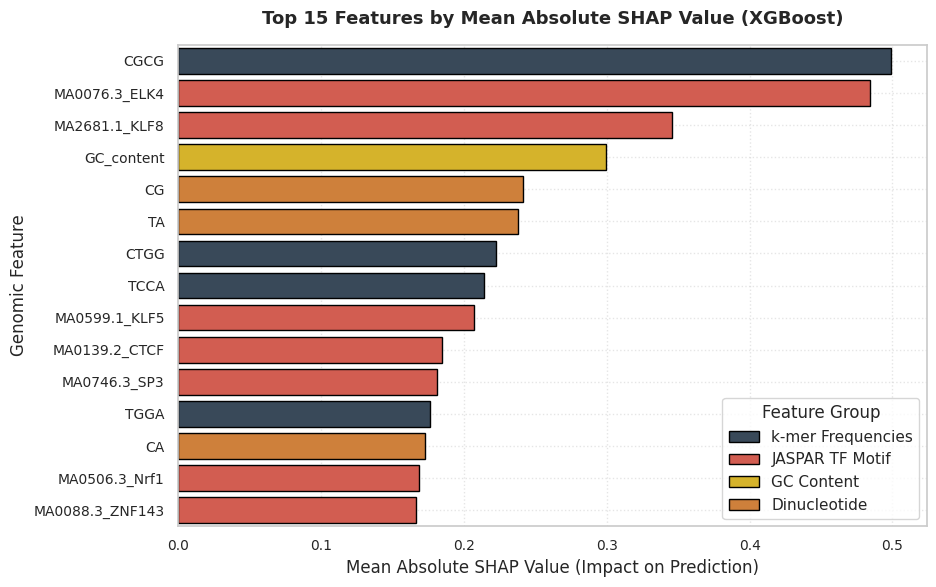


High-End Visualization Suite successfully completed and rendered.


In [18]:
import os
import time
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import train_test_split

# -----------------------------------------------------------------------------
# Setup & Style Diagnostics
# -----------------------------------------------------------------------------
print("Initializing High-End Visualization Suite (Experiment E2, E3, E7)...")
sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "figure.titlesize": 15,
    }
)
os.makedirs(plot_dir, exist_ok=True)

# =============================================================================
# VIZ 1: Experiment E2 - Feature Ablation Performance Profile
# =============================================================================
print("\n[Viz 1/6] Rendering Feature Ablation Study performance profile...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
palette_models = {
    "LOGISTIC_REGRESSION": "#3498db",
    "RANDOM_FOREST": "#2ecc71",
    "XGBOOST": "#e67e22",
}

# AUROC Comparison
sns.barplot(
    data=df_ablation,
    x="Feature Set",
    y="AUROC",
    hue="Model",
    ax=axes[0],
    palette=palette_models,
)
axes[0].set_title("Ablation Study: Test AUROC Profile", fontweight="bold", pad=10)
axes[0].set_ylim(0.65, 0.98)
axes[0].set_ylabel("Area Under ROC (AUROC)")
axes[0].set_xlabel("Feature Configuration Set")
axes[0].legend(title="Classifier", loc="lower left")

# AUPRC Comparison
sns.barplot(
    data=df_ablation,
    x="Feature Set",
    y="AUPRC",
    hue="Model",
    ax=axes[1],
    palette=palette_models,
)
axes[1].set_title("Ablation Study: Test AUPRC Profile", fontweight="bold", pad=10)
axes[1].set_ylim(0.60, 0.98)
axes[1].set_ylabel("Area Under Precision-Recall (AUPRC)")
axes[1].set_xlabel("Feature Configuration Set")
axes[1].legend(title="Classifier", loc="lower left")

plt.suptitle(
    "Experiment E2: Feature Ablation Study Performance Comparison",
    fontweight="bold",
    y=0.98,
)
plt.tight_layout()
plt.savefig(
    os.path.join(plot_dir, "phase1_ablation_profile.png"), dpi=300, bbox_inches="tight"
)
plt.show()

# =============================================================================
# VIZ 2: Experiment E3 - k-mer Resolution vs Dimensionality Trade-off
# =============================================================================
print("\n[Viz 2/6] Rendering k-mer sweep resolution trade-off...")
fig, ax1 = plt.subplots(figsize=(8.5, 5))

color_perf = "#1abc9c"
ax1.set_xlabel("k-mer Length (k)", fontweight="bold")
ax1.set_ylabel("Test Performance Metric Score", color="black")
line1 = ax1.plot(
    df_sweep["k"],
    df_sweep["AUROC"],
    marker="o",
    color=color_perf,
    linewidth=2.5,
    markersize=8,
    label="AUROC",
)
line2 = ax1.plot(
    df_sweep["k"],
    df_sweep["AUPRC"],
    marker="s",
    color="#3498db",
    linewidth=2.5,
    markersize=8,
    label="AUPRC",
)
ax1.tick_params(axis="y", labelcolor="black")
ax1.set_ylim(0.75, 0.95)

ax2 = ax1.twinx()
color_feat = "#e74c3c"
ax2.set_ylabel(
    "Feature Space Dimensionality (4^k)", color=color_feat, fontweight="bold"
)
line3 = ax2.plot(
    df_sweep["k"],
    df_sweep["Num Features"],
    marker="^",
    color=color_feat,
    linestyle="--",
    linewidth=2,
    markersize=8,
    label="Num Features",
)
ax2.tick_params(axis="y", labelcolor=color_feat)
ax2.set_yscale("log")

# Align legends
lines = line1 + line2 + line3
labels = [ln.get_label() for ln in lines]
ax1.legend(lines, labels, loc="center left")

plt.title(
    "Experiment E3: k-mer Resolution vs. Dimensionality Trade-off",
    fontweight="bold",
    pad=15,
)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.savefig(
    os.path.join(plot_dir, "phase1_kmer_tradeoff.png"), dpi=300, bbox_inches="tight"
)
plt.show()

# =============================================================================
# VIZ 3: Experiment E7 - Negative Curation Strategy & Confounding check
# =============================================================================
print("\n[Viz 3/6] Running Experiment E7 negative set sensitivity check...")
strategies = ["gc_matched", "random_unmatched", "flanking"]
e7_results = []

for strat in strategies:
    strat_tsv_path = os.path.join(processed_dir, f"k562_combined_{strat}.tsv")
    src.data.negative_sampling.build_negative_dataset(
        pos_tsv_path=extracted_tsv_path,
        fasta_source=fasta_source,
        output_path=strat_tsv_path,
        target_length=1000,
        strategy=strat,
    )
    df_strat = pd.read_csv(strat_tsv_path, sep="\t")
    X_strat, _ = extract_kmer_features(df_strat, k=4)
    y_strat = df_strat["label"].values

    if is_test_mode:
        X_tr, X_te, y_tr, y_te = train_test_split(
            X_strat, y_strat, test_size=0.2, random_state=42, stratify=y_strat
        )
    else:
        chroms = df_strat["chrom"].values
        train_mask = ~np.isin(chroms, ["chr19", "chr20", "chr21", "chr22"])
        test_mask = chroms == "chr19"
        if train_mask.sum() == 0 or test_mask.sum() == 0:
            X_tr, X_te, y_tr, y_te = train_test_split(
                X_strat, y_strat, test_size=0.2, random_state=42, stratify=y_strat
            )
        else:
            X_tr, y_tr = X_strat[train_mask], y_strat[train_mask]
            X_te, y_te = X_strat[test_mask], y_strat[test_mask]

    model_xgb = src.models.registry.ModelRegistry.get_model(
        "xgboost", {"n_estimators": 500, "n_jobs": -1, "eval_metric": "logloss"}
    )
    model_xgb.fit(X_tr, y_tr)
    y_prob = model_xgb.predict_proba(X_te)
    e7_results.append(
        {
            "Strategy": strat.replace("_", " ").upper(),
            "AUROC": roc_auc_score(y_te, y_prob),
        }
    )

df_e7 = pd.DataFrame(e7_results)

plt.figure(figsize=(7.5, 5))
color_map = ["#2ecc71", "#e74c3c", "#f1c40f"]
bars = plt.bar(
    df_e7["Strategy"], df_e7["AUROC"], color=color_map, edgecolor="black", width=0.5
)
plt.title(
    "Experiment E7: Negative Sampling Strategy Confounding Check",
    fontweight="bold",
    pad=15,
)
plt.ylabel("Test AUROC")
plt.ylim(0.70, 0.95)
plt.grid(axis="y", linestyle="--", alpha=0.5)

gc_auc = df_e7.loc[df_e7["Strategy"] == "GC MATCHED", "AUROC"].values[0]
rand_auc = df_e7.loc[df_e7["Strategy"] == "RANDOM UNMATCHED", "AUROC"].values[0]
delta_auc = abs(gc_auc - rand_auc)

plt.annotate(
    f"GC-bias delta: {delta_auc:.4f}\n(Success check: < 0.05)",
    xy=(0.5, 0.85),
    xytext=(0.5, 0.89),
    ha="center",
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", edgecolor="gray", alpha=0.95),
    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0"),
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 0.005,
        f"{height:.4f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig(
    os.path.join(plot_dir, "phase1_e7_sensitivity.png"), dpi=300, bbox_inches="tight"
)
plt.show()

# =============================================================================
# VIZ 4: Top Transcription Factor Motif Score KDE Distribution
# =============================================================================
print("\n[Viz 4/6] Rendering top motif score distribution comparison...")
motif_importances = rf_importance[rf_importance["feature"].isin(motif_names)]
if not motif_importances.empty:
    top_motif = motif_importances.iloc[0]["feature"]
    top_motif_idx = names_set_D.index(top_motif)
    df_dataset["Top_Motif_Score"] = X_set_D[:, top_motif_idx]

    plt.figure(figsize=(8.5, 5))
    sns.kdeplot(
        data=df_dataset[df_dataset["label"] == 1],
        x="Top_Motif_Score",
        fill=True,
        color="#e74c3c",
        label="Active cCREs (Positive)",
        alpha=0.5,
        linewidth=2,
    )
    sns.kdeplot(
        data=df_dataset[df_dataset["label"] == 0],
        x="Top_Motif_Score",
        fill=True,
        color="#3498db",
        label="Background (Negative)",
        alpha=0.5,
        linewidth=2,
    )

    plt.title(
        f"Genomic Signal: Score Distribution for Motif {top_motif}",
        fontweight="bold",
        pad=15,
    )
    plt.xlabel("Max-pooled Log-odds PWM Match Score")
    plt.ylabel("Density")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        os.path.join(plot_dir, "phase1_top_motif_enrichment.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
else:
    print("No TF motifs found to plot.")

# =============================================================================
# VIZ 5: ROC and Precision-Recall Curves for Best Set D Model
# =============================================================================
print("\n[Viz 5/6] Rendering ROC and PR curves for best Set D model...")
best_xgb_model = trained_models["Set D (+Motifs)"]["xgboost"]
X_te_best = split_data["Set D (+Motifs)"]["X_test"]
y_te_best = split_data["Set D (+Motifs)"]["y_test"]
y_prob_best = best_xgb_model.predict_proba(X_te_best)

fpr, tpr, _ = roc_curve(y_te_best, y_prob_best)
precision, recall, _ = precision_recall_curve(y_te_best, y_prob_best)
best_auroc = roc_auc_score(y_te_best, y_prob_best)
best_auprc = average_precision_score(y_te_best, y_prob_best)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
axes[0].plot(
    fpr, tpr, color="#2c3e50", linewidth=2.5, label=f"XGBoost (AUC = {best_auroc:.4f})"
)
axes[0].plot([0, 1], [0, 1], color="gray", linestyle="--")
axes[0].set_title("Receiver Operating Characteristic (ROC)", fontweight="bold", pad=10)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].legend(loc="lower right")

# PR Curve
axes[1].plot(
    recall,
    precision,
    color="#16a085",
    linewidth=2.5,
    label=f"XGBoost (AUPRC = {best_auprc:.4f})",
)
axes[1].set_title("Precision-Recall (PR) Curve", fontweight="bold", pad=10)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].grid(True, linestyle=":", alpha=0.6)
axes[1].legend(loc="lower left")

plt.suptitle(
    "Performance Profile: Best XGBoost Classifier on Set D Features",
    fontweight="bold",
    y=0.98,
)
plt.tight_layout()
plt.savefig(
    os.path.join(plot_dir, "phase1_best_curves.png"), dpi=300, bbox_inches="tight"
)
plt.show()

# =============================================================================
# VIZ 6: Feature Group Grouped SHAP Importance Bar Chart
# =============================================================================
print("\n[Viz 6/6] Rendering grouped SHAP feature impact bar chart...")
mean_abs_shaps = np.mean(np.abs(shap_values), axis=0)
df_shap_imp = pd.DataFrame({"feature": names_set_D, "importance": mean_abs_shaps})


def get_feature_group(name):
    if name == "GC_content":
        return "GC Content"
    elif name in dinuc_names:
        return "Dinucleotide"
    elif name in motif_names:
        return "JASPAR TF Motif"
    else:
        return "k-mer Frequencies"


df_shap_imp["Group"] = df_shap_imp["feature"].apply(get_feature_group)
df_top_shap = df_shap_imp.sort_values(by="importance", ascending=False).head(15)

plt.figure(figsize=(9.5, 6))
group_palette = {
    "k-mer Frequencies": "#34495e",
    "GC Content": "#f1c40f",
    "Dinucleotide": "#e67e22",
    "JASPAR TF Motif": "#e74c3c",
}

sns.barplot(
    data=df_top_shap,
    x="importance",
    y="feature",
    hue="Group",
    dodge=False,
    palette=group_palette,
    edgecolor="black",
)

plt.title(
    "Top 15 Features by Mean Absolute SHAP Value (XGBoost)", fontweight="bold", pad=15
)
plt.xlabel("Mean Absolute SHAP Value (Impact on Prediction)")
plt.ylabel("Genomic Feature")
plt.legend(title="Feature Group", loc="lower right")
plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig(
    os.path.join(plot_dir, "phase1_shap_feature_group_impact.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()
print("\nHigh-End Visualization Suite successfully completed and rendered.")